In [1]:
import pandas as pd
import numpy as np

import requests
import yfinance as yf
import datetime as dt

import statsmodels.api as sm
from scipy import stats
import cvxpy as cp

import matplotlib.pyplot as plt

In [2]:
TICKERS_FILE: str = 'us-tickers.txt'
DATA_COLS: list[str] = ['Open', 'High', 'Low', 'Close', 'Volume']

START_DATE: str = '2019-01-01'
END_DATE: str = '2026-05-09'

In [3]:
def get_tickers_data(tickers_path: str = TICKERS_FILE, cols: list[str] = DATA_COLS, start: str = START_DATE, end: str = END_DATE) -> pd.DataFrame:
    start_date, end_date = dt.datetime.strptime(start, "%Y-%m-%d"), dt.datetime.strptime(end, "%Y-%m-%d")

    with open(tickers_path, 'r') as f:
        tickers = [line.strip() for line in f if line.strip()]

    dfs = []
    for ticker in tickers:
        try:
            data = yf.Ticker(ticker).history(start=start_date, end=end_date)
            if data.empty:
                continue

            df = data.reset_index()
            df['Date'] = df['Date'].dt.tz_localize(None)
            df['Ticker'] = ticker
            df = df[['Date', 'Ticker'] + cols]

            dfs.append(df)

        except Exception:
            continue

    # combine all tickers
    full_df = pd.concat(dfs, ignore_index=True)

    full_df = full_df.set_index(['Date', 'Ticker']).sort_index()

    return full_df.dropna()

In [4]:
def clean_ohclv_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df[(df[['Open','High','Low','Close']] > 0).all(axis=1)]
    df = df[df.groupby(level='Ticker')['Close'].diff() != 0]
    return df

In [ ]:
def calculate_forward_return(df: pd.DataFrame) -> pd.DataFrame:
    """(Open_t+2/Open_t+1) - 1"""
    df['forward_ret'] = df.groupby('Ticker')['Open'].transform(lambda x: x.shift(-2) / x.shift(-1) - 1)
    return df

def calculate_factor_return(df: pd.DataFrame, window: int) -> pd.Series:
    """(Close_t0 / Close_t-n) - 1"""
    return df['Close'] / df.groupby('Ticker')['Close'].shift(window) - 1

def calculate_factor_log_return(df: pd.DataFrame, window: int) -> pd.Series:
    """log(Close_t0 / Close_t-n)"""
    return np.log(df['Close'] / df.groupby('Ticker')['Close'].shift(window))

def calculate_factor_ret_ratio(df: pd.DataFrame, wdw1: int, wdw2: int) -> pd.Series:
    prev_ret = df.groupby('Ticker')['Close'].shift(wdw1) / df.groupby('Ticker')['Close'].shift(wdw1 + wdw2) - 1
    latest_ret = df['Close'] / df.groupby('Ticker')['Close'].shift(wdw2) - 1

    ratios = latest_ret / prev_ret
    ratios = ratios.replace([np.inf, -np.inf], np.nan)
    return ratios

def calculate_factor_momentum_diff(df: pd.DataFrame, wdw1: int, wdw2: int) -> pd.Series:
    prev_ret = df.groupby('Ticker')['Close'].shift(wdw1) / df.groupby('Ticker')['Close'].shift(wdw1 + wdw2) - 1
    latest_ret = df['Close'] / df.groupby('Ticker')['Close'].shift(wdw2) - 1

    diffs = latest_ret - prev_ret
    diffs = diffs.replace([np.inf, -np.inf], np.nan)

    return diffs

def calculate_factor_clv(df: pd.DataFrame) -> pd.Series:
    """(Close - Low - (High - Close)) / (High - Low)"""
    clv = (df['Close'] - df['Low'] - (df['High'] - df['Close'])) / (df['High'] - df['Low'])
    clv = clv.replace([np.inf, -np.inf], np.nan)
    return clv

In [6]:
def winsorize_forward_return(df: pd.DataFrame, lower: float = 0.00001, upper: float = 0.99995) -> None:
    lower_val = df['forward_ret'].quantile(lower)
    upper_val = df['forward_ret'].quantile(upper)

    df['forward_ret'] = df['forward_ret'].clip(lower_val, upper_val)
    return

In [7]:
def standardize_zscore(factor_series: pd.Series, n = 2.5) -> pd.Series:
    """
    因子载荷原始值标准化
    """
    # 计算中位数和MAD
    median = factor_series.median()
    mad = np.median(np.abs(factor_series - median))

    # 标准化
    factors = factor_series.clip(lower=median - n * mad, upper=median + n * mad)
    factors = (factors - factors.mean()) / factors.std()

    return factors

def standardize_rank(factor_series: pd.Series) -> pd.Series:
    """
    因子载荷排序值标准化
    """
    factors = factor_series.rank(method='average')
    factors = (factors - factors.mean()) / factors.std()

    return factors

def standardize_factor(df: pd.DataFrame, factor_col: str) -> pd.DataFrame:
    """
    因子值标准化
    """
    df[factor_col + '_zscore'] = df.groupby('Date')[factor_col].transform(standardize_zscore)
    df[factor_col + '_ranked'] = df.groupby('Date')[factor_col].transform(standardize_rank)

    return df

In [8]:
def get_residual(X: pd.DataFrame, factor_col: str, control_col: str) -> pd.Series:
    X = X.dropna(subset=[factor_col, control_col])
    if len(X) < 100:
        return pd.Series(np.nan, index=X.index)

    X = sm.add_constant(X)
    y = X[factor_col]

    model = sm.OLS(y, X.astype(float), missing='drop').fit()
    return model.resid

def neutralize_factor(df: pd.DataFrame, factor: str, control: str) -> pd.DataFrame:
    df[factor + "_neu"] = df.groupby('Date').apply(lambda x: get_residual(x, factor, control)).reset_index(level=0, drop=True)

    return df

In [9]:
def calculate_ic_and_tstat(df: pd.DataFrame, factor: str) -> dict[str, pd.Series | float]:
    def ic_func(x: pd.DataFrame):
        tmp = x[[factor, 'forward_ret']].dropna()
        if len(tmp) < 40:
            return np.nan
        
        return stats.spearmanr(tmp[factor], tmp['forward_ret'])[0]
    
    ic_series = df.groupby('Date').apply(ic_func).dropna()

    ic_mean, ic_stdev = ic_series.mean(), ic_series.std()

    ir = ic_mean / ic_stdev if ic_stdev != 0 else np.nan

    t_stat, p_val = stats.ttest_1samp(ic_series, 0)

    metrics = {
        'IC Series': ic_series,
        'IC Mean': ic_mean,
        'IC_Std': ic_stdev,
        'IR': ir,
        't-stat': t_stat,
        'p-value': p_val
    }    

    return metrics

In [10]:
def stratify(x: pd.Series, num_groups: int) -> pd.Series:
    return pd.qcut(x.rank(method='first'), q=num_groups, labels=False, duplicates='drop') + 1

def stratified_backtest(df: pd.DataFrame, factor: str, num_groups: int, risk_free_rate: float = 0.03) -> tuple[pd.DataFrame, dict[pd.Series]]:
    df_copy = df.copy()
    df_copy['Group'] = df_copy.groupby('Date')[factor].transform(lambda x: stratify(x, num_groups))

    group_returns = df_copy.groupby(['Date', 'Group'])['forward_ret'].mean().unstack()

    group_performances, cum_returns = [], {}
    for g in range(1, num_groups + 1):
        annual_return = group_returns[g].mean() * 252

        annual_volatility = group_returns[g].std() * np.sqrt(252)

        sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility if annual_volatility != 0 else np.nan

        equity_curve = (1 + group_returns[g]).cumprod()

        max_drawdown = ((equity_curve.cummax() - equity_curve) / equity_curve.cummax()).max()

        group_performances.append({
            'Group': g,
            'Annual Return': annual_return,
            'Annual Volatility': annual_volatility,
            'Sharpe Ratio': sharpe_ratio,
            'Max Drawdown': max_drawdown
        })

        cum_returns[g] = equity_curve - 1
    
    return pd.DataFrame(group_performances).set_index('Group'), cum_returns

In [11]:
def plot_results(ic_info: dict[str, dict[str]], backtest_results: dict[str, tuple[pd.DataFrame, dict[pd.Series]]], 
                 factors: list[str]) -> None:
    """
    绘制结果图表
    """
    fig, axes = plt.subplots(len(factors), 4, figsize=(18, 5 * len(factors)))
    if len(factors) == 1:
        axes = [axes]
    fig.suptitle('Factor Analysis Results', fontsize=14, y=1.01)

    for i, factor in enumerate(factors):
        group_stats, group_cum_rets = backtest_results[factor]
        ax_ic, ax_table, ax_cr, ax_gs = axes[i]

        # cumulative IC
        ic_series = ic_info[factor]['IC Series']
        cumulative_ic = ic_series.cumsum()
        ax_ic.plot(cumulative_ic.index, cumulative_ic.values, label='Cumulative IC')
        ax_ic.axhline(0, color='black', linewidth=0.5, linestyle='--')
        ax_ic.set_title(f'{factor} — cumulative IC')
        ax_ic.tick_params(axis='x', rotation=45)
        ax_ic.grid(True, alpha=0.5)

        # IC stats table
        ax_table.axis('off')
        ic = ic_info[factor]
        table_data = [[k, f'{v:.5f}'] for k, v in ic.items() if k not in ['IC Series', 'IC_Std']]
        table = ax_table.table(cellText=table_data, colLabels=['Metric', 'Value'],
                               loc='center', cellLoc='left')
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 2)
        ax_table.set_title(f'{factor} — IC stats')

        # cumulative returns
        for group, curve in group_cum_rets.items():
            ax_cr.plot(curve.index, curve.values, label=f'Group {group}')
        ax_cr.set_title(f'{factor} — cumulative returns')
        ax_cr.legend(fontsize=8)
        ax_cr.set_xlabel('')
        ax_cr.tick_params(axis='x', rotation=45)
        ax_cr.grid(True, alpha=0.5)

        # group stats bar chart
        stats = group_stats[factor] if isinstance(group_stats, dict) else group_stats
        x = np.arange(len(stats))
        width = 0.2
        for j, col in enumerate(stats.columns):
            ax_gs.bar(x + j * width, stats[col].values, width=width, label=col)
        ax_gs.set_xticks(x + width * (len(stats.columns) - 1) / 2)
        ax_gs.set_xticklabels([f'G{g}' for g in stats.index])
        ax_gs.axhline(0, color='black', linewidth=0.5)
        ax_gs.legend(fontsize=7)
        ax_gs.set_title(f'{factor} — group stats')

    plt.tight_layout()
    plt.show()

In [12]:
def optimize_portfolio(df: pd.DataFrame, date: str, factor: str, n: int, ic_positive: bool, penalty: float, w_range: tuple[float, float]) -> pd.Series:
    """
    优化投资组合
    """
    cross_section = df.loc[date].copy().dropna() # 获取指定日期的截面数据
    if len(cross_section) == 0:
        return pd.Series(dtype=float)

    # 选择因子值最小的n只股票
    mini_n = cross_section.nsmallest(n, factor).copy()

    exp_ret = mini_n[factor].values if ic_positive else -mini_n[factor].values # 因子值作为预期收益率

    w = cp.Variable(len(mini_n)) # 权重变量
    Sigma = np.eye(len(mini_n)) # 协方差矩阵（假设为单位矩阵）

    objective = cp.Maximize(exp_ret @ w - penalty * cp.quad_form(w, Sigma)) # 目标函数
    constraints = [cp.sum(w) == 1, w >= w_range[0], w <= w_range[1]] # 权重约束
    
    problem = cp.Problem(objective, constraints)
    problem.solve()

    return pd.Series(np.clip(w.value, w_range[0], w_range[1]), index=mini_n.index) if w.value is not None else pd.Series(1 / len(mini_n), index=mini_n.index)

def get_long_positions(df: pd.DataFrame, factor: str, n: int = 5, ic_positive: bool = False,
                       penalty: float = 0.05, w_range: tuple[float, float] = (0, 0.25)) -> pd.DataFrame:
    """
    构建投资组合
    """
    all_tickers = df.index.get_level_values('Ticker').unique()
    
    results = {}
    for date in df.index.get_level_values('Date').unique():
        weights = optimize_portfolio(df, date, factor, n, ic_positive, penalty, w_range)
        weights = weights.reindex(all_tickers, fill_value=0)
        results[date] = weights
    
    portfolio = pd.concat(results, axis=1).T
    
    # stack to (Date, Ticker) MultiIndex, drop NaN (unselected stocks)
    portfolio = portfolio.stack().to_frame('position')
    portfolio.index.names = ['Date', 'Ticker']

    df['position'] = portfolio['position']
    return df

In [13]:
def get_mini_long_short_positions(df: pd.DataFrame, factor: str, ic_positive: bool, n: int = 2) -> pd.DataFrame:
    df['rank'] = df.groupby('Date')[factor].rank(pct=True)
    counts = df.groupby('Date')[factor].transform('count')

    df['position'] = 0
    if ic_positive:
        df.loc[df['rank'] > counts - n, 'position'] = 1
        df.loc[df['rank'] <= n, 'position'] = -1
    else:
        df.loc[df['rank'] >= counts - n, 'position'] = -1
        df.loc[df['rank'] <= n, 'position'] = 1
    df['position'] = df['position'].groupby('Date').transform(lambda x: x / x.abs().sum() if x.abs().sum() != 0 else x)
    
    df.loc[df[factor].isna(), 'position'] = 0

    df = df.drop(columns=['rank'])
    return df

def get_long_short_positions(df: pd.DataFrame, factor: str, ic_positive: bool) -> pd.DataFrame:
    df['rank'] = df.groupby('Date')[factor].rank(pct=True)

    df['position'] = 0
    if ic_positive:
        df.loc[df['rank'] >= 0.8, 'position'] = 1
        df.loc[df['rank'] <= 0.2, 'position'] = -1
    else:
        df.loc[df['rank'] >= 0.8, 'position'] = -1
        df.loc[df['rank'] <= 0.2, 'position'] = 1
    df['position'] = df['position'].groupby('Date').transform(lambda x: x / x.abs().sum() if x.abs().sum() != 0 else x)
    
    df.loc[df[factor].isna(), 'position'] = 0

    df = df.drop(columns=['rank'])
    return df

In [14]:
def backtest_positions(df: pd.DataFrame, risk_free_rate: float = 0.03) -> tuple[pd.DataFrame, pd.Series]:
    df_copy = df.copy()

    df_copy['strategy_ret'] = df_copy['position'] * df_copy['forward_ret']

    daily_returns = df_copy.groupby('Date')['strategy_ret'].sum()

    annual_return = daily_returns.mean() * 252
    annual_volatility = daily_returns.std() * np.sqrt(252)

    sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility if annual_volatility != 0 else np.nan

    equity_curve = (1 + daily_returns).cumprod()

    max_drawdown = ((equity_curve.cummax() - equity_curve) / equity_curve.cummax()).max()

    performance = {
        'Annual Return': annual_return,
        'Annual Volatility': annual_volatility,
        'Sharpe Ratio': sharpe_ratio,
        'Max Drawdown': max_drawdown
    }

    return performance, equity_curve

In [15]:
def plot_portfolio_performance(equity_curve: pd.Series, metrics: dict) -> None:
    """
    绘制投资组合表现图表
    """
    plt.figure(figsize=(10, 6))
    plt.plot(equity_curve.index, equity_curve.values, label='Portfolio Equity Curve')
    plt.title('Portfolio Performance')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.grid()
    plt.legend()
    
    # 显示性能指标
    textstr = '\n'.join([f'{k}: {v:.4f}' for k, v in metrics.items()])
    props = dict(boxstyle='round', facecolor='white', alpha=0.5)
    plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='top', bbox=props)
    
    plt.show()

In [16]:
df = pd.read_parquet('data.parquet')

In [ ]:
df = calculate_forward_return(df)

factor_col = 'clv'
# df[factor_col] = calculate_factor_return(df, window=3)  # good
# df[factor_col] = calculate_factor_log_return(df, window=3)  # good
# df[factor_col] = calculate_factor_ret_ratio(df, wdw1=3, wdw2=2)  # ineffective
# df[factor_col] = calculate_factor_momentum_diff(df, wdw1=3, wdw2=3)  # mid
df[factor_col] = calculate_factor_clv(df)

In [18]:
# ticker = 'EP'

# tmp = df.xs(ticker, level='Ticker')

# tmp.loc['2020-03-01':'2020-04-30']

In [19]:
df = clean_ohclv_data(df)

In [20]:
winsorize_forward_return(df, 0.00005, 0.9999)

In [21]:
df = standardize_factor(df, factor_col)

In [22]:
ic_info, backtest_results = {}, {}
for factor in [factor_col, factor_col + '_zscore', factor_col + '_ranked']:
    metrics = calculate_ic_and_tstat(df, factor)
    group_performances, cum_returns = stratified_backtest(df, factor, 5)

    ic_info[factor] = metrics
    backtest_results[factor] = (group_performances, cum_returns)

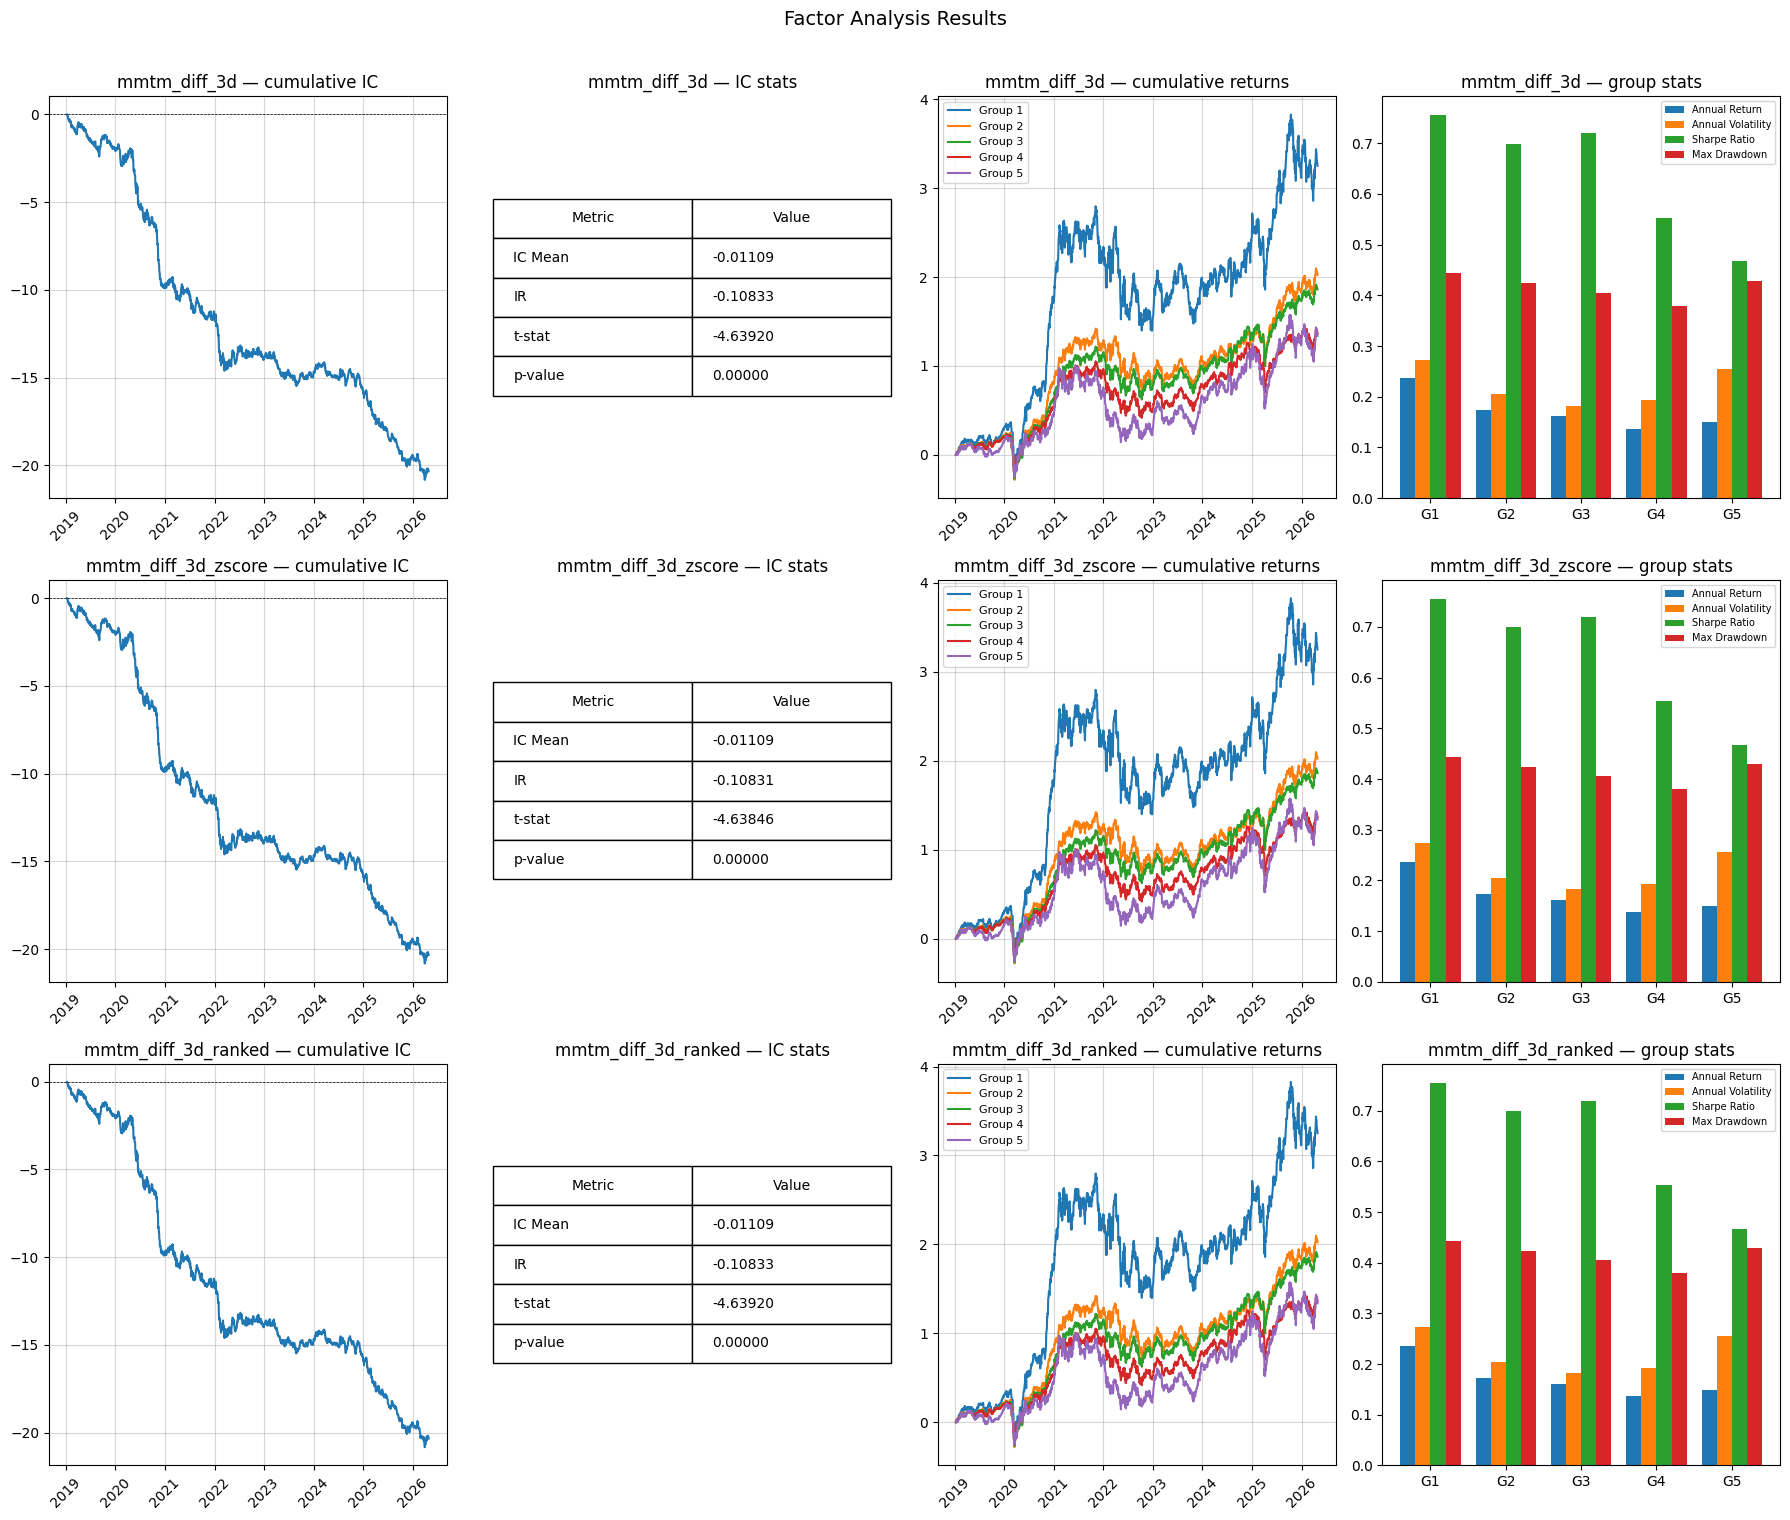

In [23]:
plot_results(ic_info, backtest_results, factors = [factor_col, factor_col + '_zscore', factor_col + '_ranked'])

In [24]:
df = get_mini_long_short_positions(df, factor_col, ic_positive=False)

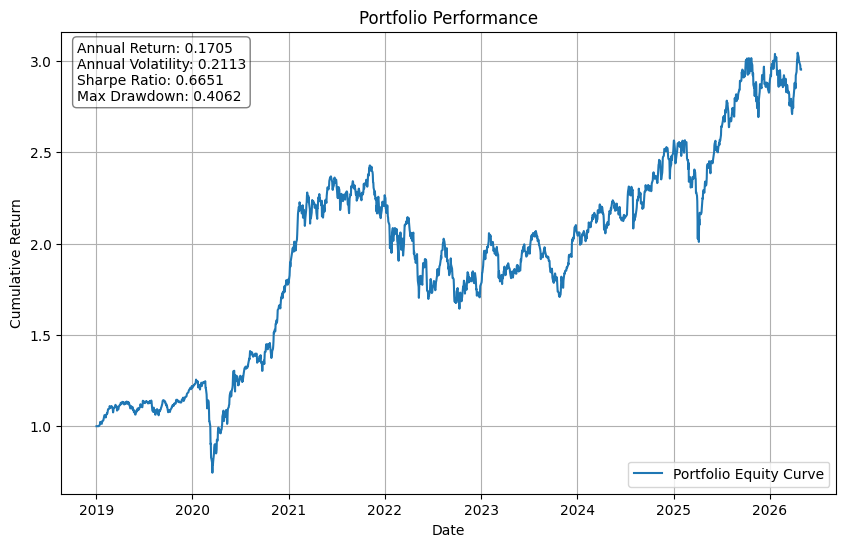

In [25]:
mini_long_short_metrics, mini_long_short_equity_curve = backtest_positions(df)

plot_portfolio_performance(mini_long_short_equity_curve, mini_long_short_metrics)

In [26]:
df = get_long_short_positions(df, factor_col, ic_positive=False)

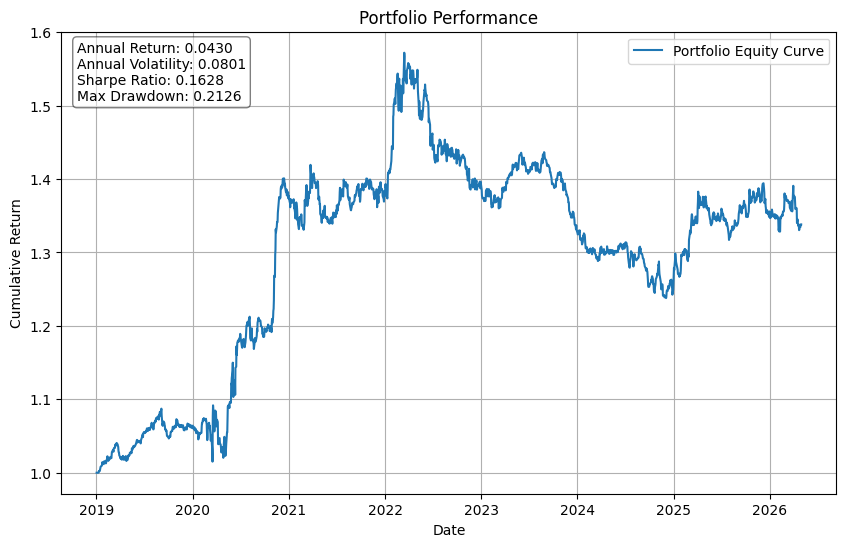

In [27]:
long_short_metrics, long_short_equity_curve = backtest_positions(df)

plot_portfolio_performance(long_short_equity_curve, long_short_metrics)

In [28]:
df = get_long_positions(df, factor_col, n=100, ic_positive=False, w_range=(0, 0.1))

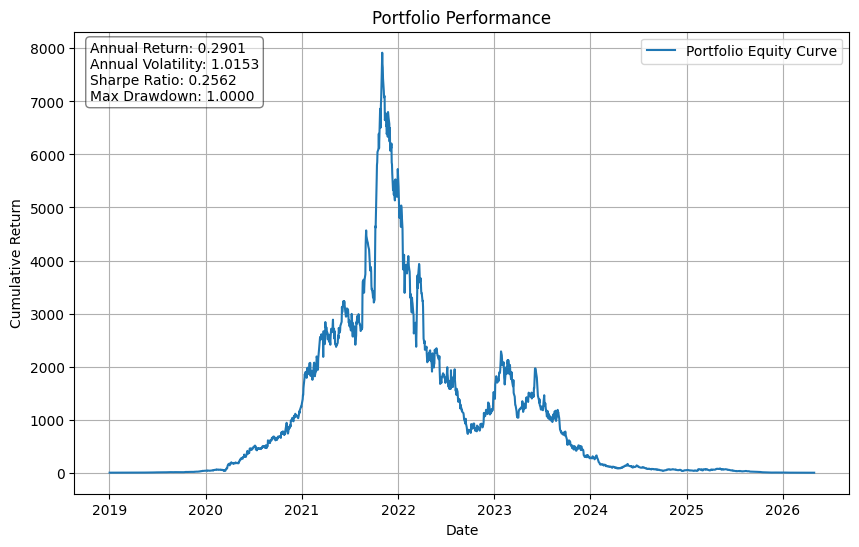

In [29]:
long_portfolio_metrics, long_portfolio_equity_curve = backtest_positions(df)

plot_portfolio_performance(long_portfolio_equity_curve, long_portfolio_metrics)

In [30]:
def get_tickers_to_trade(df: pd.DataFrame, date: str, factor: str, ic_positive: bool, n: int) -> dict[int, str]:
    df['rank'] = df.groupby('Date')[factor].rank(method='first', pct=True)

    day = df.xs(date, level='Date')

    buy_tickers = day.nlargest(n, 'rank').index.tolist() if ic_positive else day.nsmallest(n, 'rank').index.tolist()
    sell_tickers = day.nsmallest(n, 'rank').index.tolist() if ic_positive else day.nlargest(n, 'rank').index.tolist()

    return {'Buy': buy_tickers, 'Sell': sell_tickers}

In [ ]:
df_today = get_tickers_data(start='2026-05-02', end='2026-05-09')

Exception ignored from cffi callback <function buffer_callback at 0xf1bb6d30e340>:
Traceback (most recent call last):
  File "/home/lawre/trials-and-errors/venv/lib/python3.12/site-packages/curl_cffi/curl.py", line 125, in buffer_callback
    @ffi.def_extern()
    
KeyboardInterrupt: 
$ACT: possibly delisted; no price data found  (1d 2026-05-02 00:00:00 -> 2026-05-09 00:00:00)
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AHL"}}}
$AHL: possibly delisted; no timezone found


In [ ]:
df_today[factor_col] = calculate_factor_return(df_today, window=3)

df_today = clean_ohclv_data(df_today)

In [ ]:
portfolio_list = get_tickers_to_trade(df_today, '2026-05-07', factor_col, False, 2)

In [ ]:
portfolio_list

{'Buy': ['GDC', 'BNZI'], 'Sell': ['CVNA', 'AGL']}

In [ ]:
df_today.xs('GDC', level='Ticker')

,Open,High,Low,Close,Volume,ret_3d,rank
Date,,,,,,,
2026-05-04,4.44,4.97,4.4000,4.900,133400,NaN,NaN
2026-05-05,4.67,5.99,3.1300,5.990,1360000,NaN,NaN
2026-05-06,7.50,8.18,1.1900,1.240,18041100,NaN,NaN
2026-05-07,1.40,1.41,0.1366,0.151,203085824,-0.969184,0.000184
